# German Electricity Demand - Time-Series Forecasting 

This is the **primary** notebook for the assignment. It loads German electricity load, aggregates
to weekly/daily values, performs EDA and stationarity testing, then builds and compares benchmark,
SARIMA, SARIMAX, feature-based (Random Forest) and LSTM forecasts over a 2-year horizon.

**Correctness improvements addressed in this version**
- SARIMA order is selected with a statistically valid procedure: AIC is only compared *within* a
  fixed differencing order, and the final model is chosen with automatic reporting of AIC,
  convergence status and residual diagnostics.
- The seasonal orders (P, Q) are searched over a small, justified space (P, Q ∈ {0,1}) rather than silently fixed, with D = 1 fixed from the annual-cycle evidence.
- Residual diagnostics use standardized residuals with the state-space burn-in removed.
- The Random Forest is evaluated as a genuine recursive multi-step forecast so it is comparable to
  SARIMA/SARIMAX; a 1-step variant is reported separately.
- LSTM rolling vs open-loop weekly errors are computed and labelled correctly.
- RMSE, MAE and MAPE are reported for every model, with an explicit forecast-type column.

## 1. Data Preparation and Exploratory Analysis

The hourly Open Power System Data for Germany (`DE_load_actual_entsoe_transparency`) is loaded,
observations from 1 January 2015 onwards are kept, and the series is aggregated to daily and weekly
means. Weekly aggregation removes intra-week volatility and exposes the annual cycle used by the
classical models.

In [ ]:
!pip install holidays -q
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import holidays
from statsmodels.tsa.seasonal import seasonal_decompose

plt.style.use('seaborn-v0_8-darkgrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load the local hourly dataset (Open Power System Data, Germany)
raw_df = pd.read_csv(
    'opsd_60min_raw.csv',
    parse_dates=['utc_timestamp'], index_col='utc_timestamp'
)
print('Total rows:', raw_df.shape[0])

Total rows: 50401


In [2]:
# Isolate the German actual load and slice the required date range
target_col = 'DE_load_actual_entsoe_transparency'
elec_df = raw_df[[target_col]].copy()
elec_df.rename(columns={target_col: 'load_mw'}, inplace=True)

elec_df = elec_df.loc['2015-01-01':'2020-10-31'].dropna()
print(f'Data range: {elec_df.index.min()} to {elec_df.index.max()}')
print('Hourly observations:', len(elec_df))

Data range: 2015-01-01 00:00:00+00:00 to 2020-09-30 23:00:00+00:00
Hourly observations: 50400


In [3]:
# Aggregate to daily and weekly means
daily_avg = elec_df['load_mw'].resample('D').mean()
weekly_avg = elec_df['load_mw'].resample('W').mean()
print('Missing weekly values?', weekly_avg.isna().any())
print('Weekly observations:', len(weekly_avg))

Missing weekly values? False
Weekly observations: 301


In [4]:
print('--- Daily summary ---')
print(daily_avg.describe())
print('\n--- Weekly summary ---')
print(weekly_avg.describe())

--- Daily summary ---
count     2100.000000
mean     55492.468552
std       6601.474342
min      38952.666667
25%      50413.447917
50%      56776.916667
75%      60430.093750
max      68183.583333
Name: load_mw, dtype: float64

--- Weekly summary ---
count      301.000000
mean     55484.350477
std       3762.742475
min      46505.309524
25%      52845.267857
50%      54858.434524
75%      58688.470238
max      63587.011905
Name: load_mw, dtype: float64


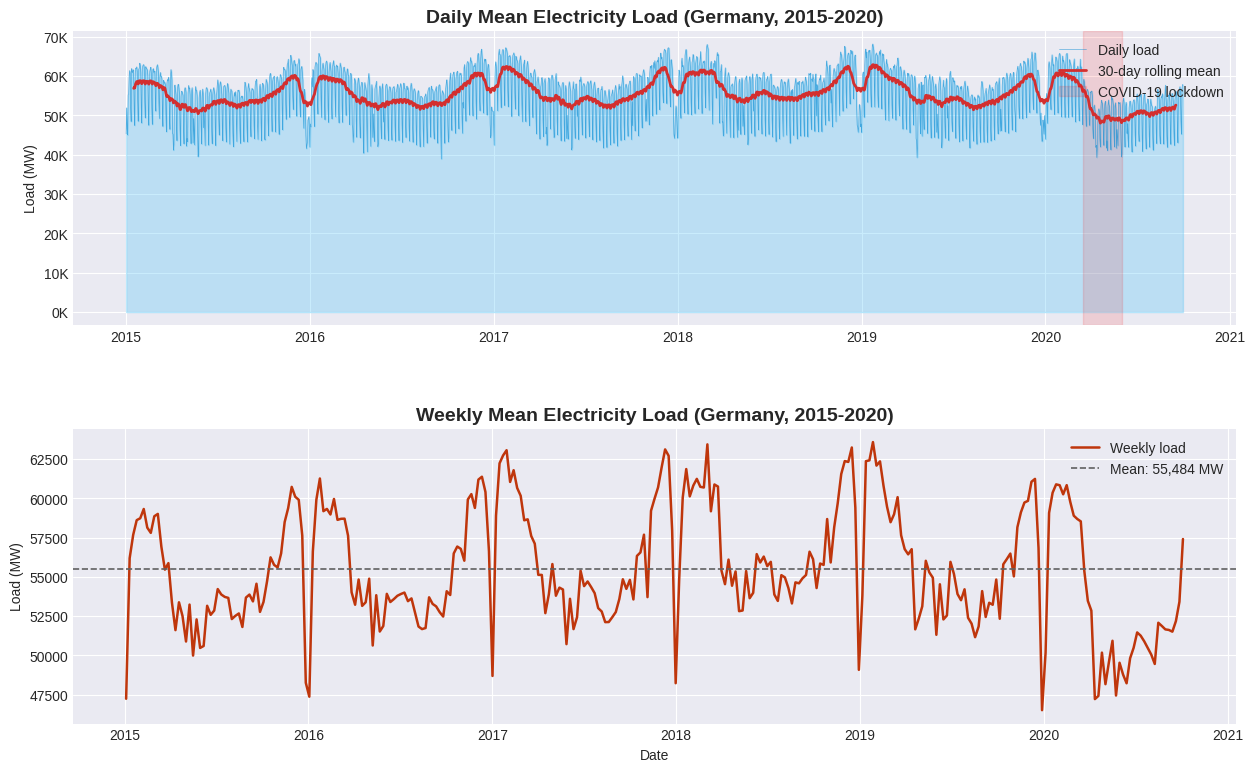

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9), gridspec_kw={'hspace': 0.35})

ax = axes[0]
ax.fill_between(daily_avg.index, daily_avg, color='#4FC3F7', alpha=0.3)
ax.plot(daily_avg.index, daily_avg, color='#0288D1', linewidth=0.5, alpha=0.6, label='Daily load')
daily_smooth = daily_avg.rolling(30, center=True).mean()
ax.plot(daily_smooth.index, daily_smooth, color='#D32F2F', linewidth=2.0, label='30-day rolling mean')
ax.axvspan(pd.Timestamp('2020-03-15'), pd.Timestamp('2020-06-01'), alpha=0.12, color='red',
           label='COVID-19 lockdown')
ax.set_title('Daily Mean Electricity Load (Germany, 2015-2020)', fontsize=14, fontweight='bold')
ax.set_ylabel('Load (MW)')
ax.legend(loc='upper right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

ax2 = axes[1]
ax2.plot(weekly_avg.index, weekly_avg, color='#BF360C', linewidth=1.8, label='Weekly load')
ax2.axhline(weekly_avg.mean(), color='#616161', linestyle='--', linewidth=1.2,
            label=f'Mean: {weekly_avg.mean():,.0f} MW')
ax2.set_title('Weekly Mean Electricity Load (Germany, 2015-2020)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Load (MW)')
ax2.set_xlabel('Date')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

Electricity usage falls in summer and peaks in winter, indicating strong annual seasonality. An
additive seasonal decomposition with `period=52` isolates the trend, the annual seasonal component
and the residual. (Decomposition drops ~26 weeks at each end to compute the centred moving-average
trend, so the residual contains NaNs there.)

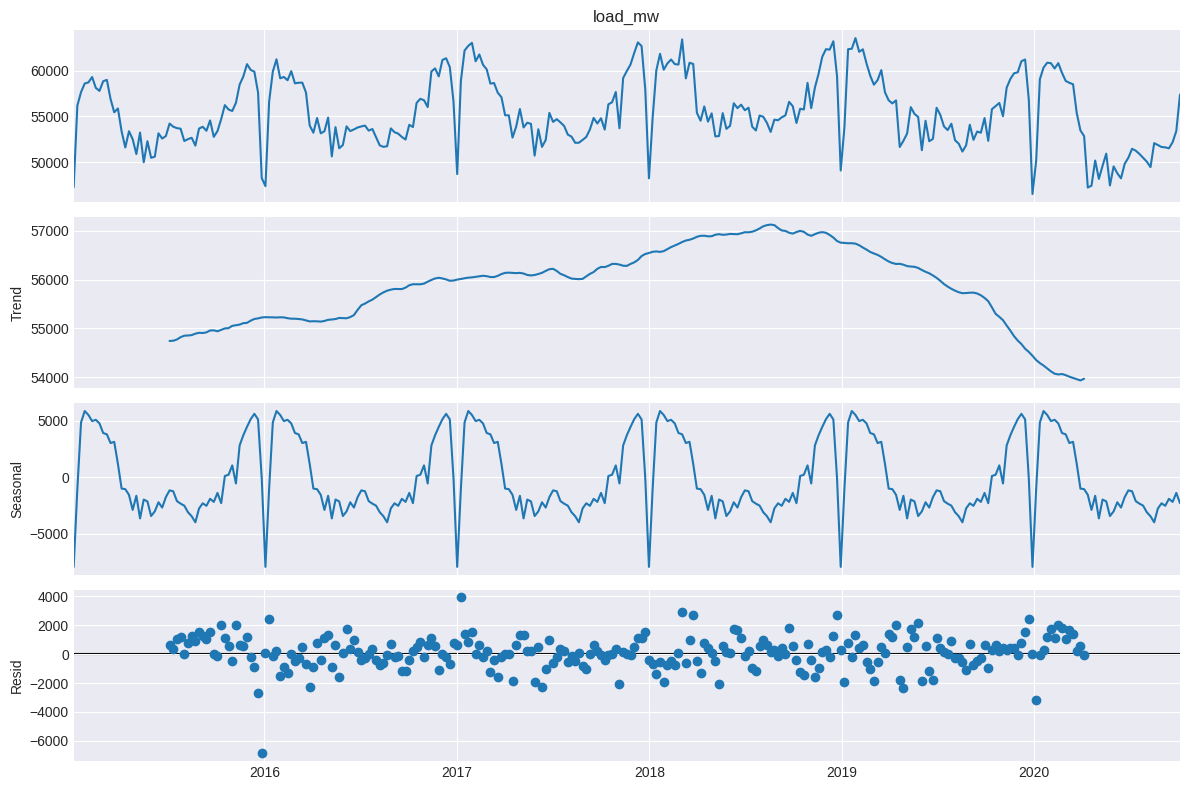

Residual NaNs from decomposition: 52


In [6]:
decomp = seasonal_decompose(weekly_avg, model='additive', period=52)
fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()
print('Residual NaNs from decomposition:', int(decomp.resid.isna().sum()))

The next step tests for non-stationarity with the Augmented Dickey-Fuller (ADF) and KPSS tests and
inspects the ACF/PACF of the raw and differenced series.

--- Weekly load (raw) ---
ADF : stat=  -4.047  p=0.0012  -> stationary
KPSS: stat=   0.160  p=0.1000  -> stationary

--- Weekly load (1st difference) ---
ADF : stat=  -7.069  p=0.0000  -> stationary
KPSS: stat=   0.056  p=0.1000  -> stationary

--- Weekly load (seasonal difference, lag 52) ---
ADF : stat=  -4.295  p=0.0005  -> stationary
KPSS: stat=   1.342  p=0.0100  -> non-stationary



/tmp/ipykernel_58/4035965991.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(s, regression='c', nlags='auto')
/tmp/ipykernel_58/4035965991.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(s, regression='c', nlags='auto')
/tmp/ipykernel_58/4035965991.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kp = kpss(s, regression='c', nlags='auto')


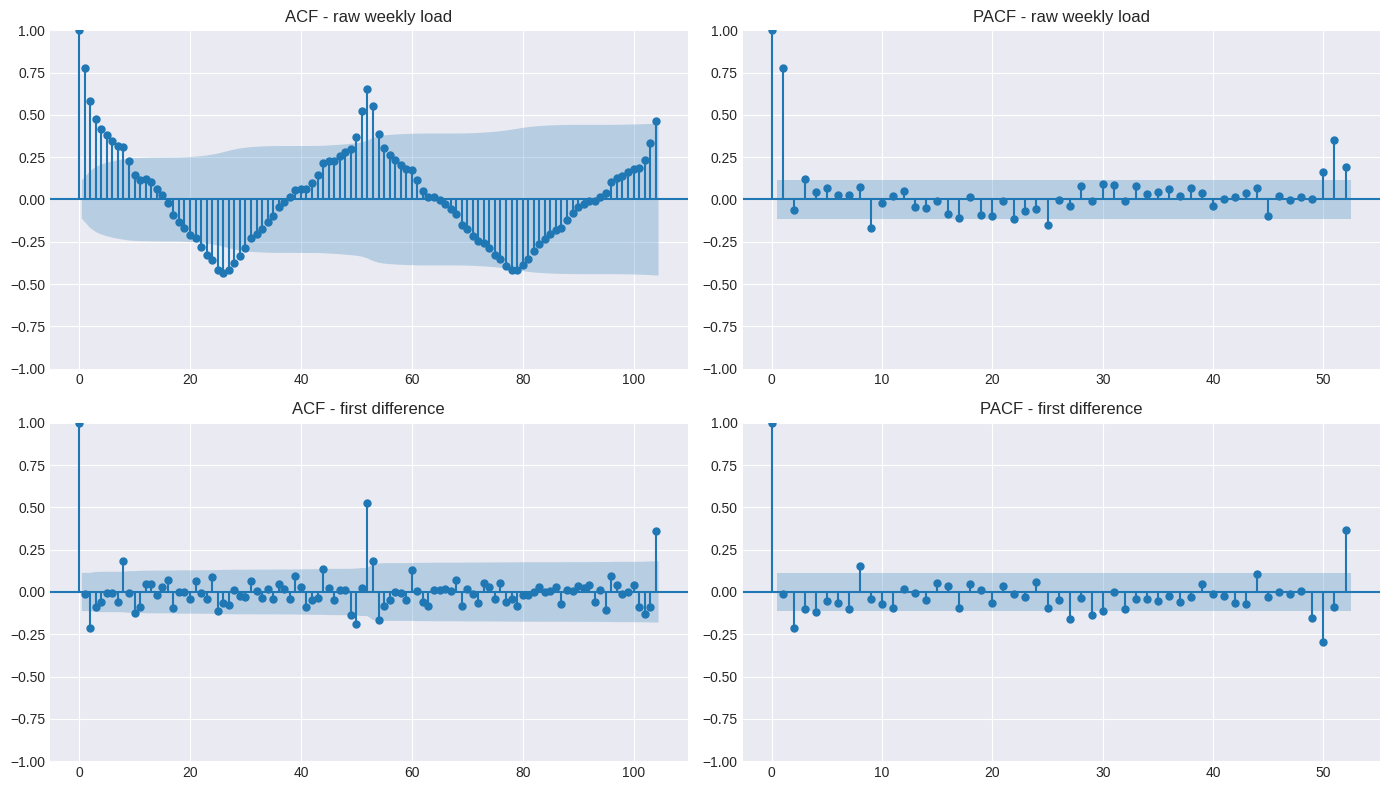

In [7]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def stationarity_report(series, label):
    s = series.dropna()
    adf = adfuller(s)
    kp = kpss(s, regression='c', nlags='auto')
    adf_verdict = 'stationary' if adf[1] <= 0.05 else 'non-stationary'
    kpss_verdict = 'non-stationary' if kp[1] < 0.05 else 'stationary'
    print(f'--- {label} ---')
    print(f'ADF : stat={adf[0]:8.3f}  p={adf[1]:.4f}  -> {adf_verdict}')
    print(f'KPSS: stat={kp[0]:8.3f}  p={kp[1]:.4f}  -> {kpss_verdict}')
    print()

stationarity_report(weekly_avg, 'Weekly load (raw)')
stationarity_report(weekly_avg.diff(), 'Weekly load (1st difference)')
stationarity_report(weekly_avg.diff(52), 'Weekly load (seasonal difference, lag 52)')

fig, ax = plt.subplots(2, 2, figsize=(14, 8))
plot_acf(weekly_avg.dropna(), ax=ax[0, 0], lags=104, title='ACF - raw weekly load')
plot_pacf(weekly_avg.dropna(), ax=ax[0, 1], lags=52, title='PACF - raw weekly load', method='ywm')
plot_acf(weekly_avg.diff().dropna(), ax=ax[1, 0], lags=104, title='ACF - first difference')
plot_pacf(weekly_avg.diff().dropna(), ax=ax[1, 1], lags=52, title='PACF - first difference', method='ywm')
plt.tight_layout()
plt.show()

### Stationarity: interpretation and differencing choice

The ADF test rejects the unit-root null on the **raw** weekly series (p < 0.05) and KPSS does not
reject stationarity, so the level series is already close to mean-stationary. However, the ACF
decays slowly with a clear spike near lag 52, and the decomposition shows a strong annual cycle.
For a **seasonal** ARIMA the choice is therefore to:

- take one **seasonal** difference (`D = 1`, `s = 52`) to remove the annual pattern, and
- take one **regular** difference (`d = 1`) to remove the residual local level drift that seasonal
  differencing leaves behind.

`d = 2` is rejected: the series is stationary after a single difference, so a second difference
over-differences it (inflating variance and injecting a spurious negative MA(1) term). This choice
is confirmed statistically in the SARIMA selection section below.

## 2. Benchmark Models

Before any complex model, benchmarks are established. The last **104 weeks (2 years)** are held out
as the test set, and four classical forecasts are evaluated: Mean, Naive, Seasonal Naive and Drift.
Every model in this notebook is scored with RMSE, MAE and MAPE through a single helper.

In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

forecast_horizon = 104  # 2 years of weekly data
train_series = weekly_avg.iloc[:-forecast_horizon]
test_series = weekly_avg.iloc[-forecast_horizon:]
print(f'Train: {train_series.shape[0]} weeks  |  Test: {test_series.shape[0]} weeks')
print(f'Train end: {train_series.index[-1].date()}  |  Test end: {test_series.index[-1].date()}')

def evaluate(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100.0
    return rmse, mae, mape

def get_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(np.asarray(y_true, dtype=float),
                                      np.asarray(y_pred, dtype=float)))

Train: 197 weeks  |  Test: 104 weeks
Train end: 2018-10-07  |  Test end: 2020-10-04


In [9]:
# 1. Mean forecast
mean_preds = pd.Series(train_series.mean(), index=test_series.index)
# 2. Naive forecast (last observed value)
naive_preds = pd.Series(train_series.iloc[-1], index=test_series.index)
# 3. Seasonal naive (repeat the last 52 weeks)
s_length = 52
last_cycle = train_series.iloc[-s_length:].values
reps = int(np.ceil(forecast_horizon / s_length))
s_naive_preds = pd.Series(np.tile(last_cycle, reps)[:forecast_horizon], index=test_series.index)
# 4. Drift forecast (extrapolate the average slope)
slope = (train_series.iloc[-1] - train_series.iloc[0]) / (len(train_series) - 1)
drift_preds = pd.Series(train_series.iloc[-1] + np.arange(1, forecast_horizon + 1) * slope,
                        index=test_series.index)

benchmark_preds = {'Mean': mean_preds, 'Naive': naive_preds,
                   'Seasonal Naive': s_naive_preds, 'Drift': drift_preds}
print('--- Benchmark scores ---')
for name, pred in benchmark_preds.items():
    rmse, mae, mape = evaluate(test_series, pred)
    print(f'{name:15s}  RMSE={rmse:8.1f}  MAE={mae:8.1f}  MAPE={mape:5.2f}%')

--- Benchmark scores ---
Mean             RMSE=  4397.3  MAE=  3788.8  MAPE= 6.97%
Naive            RMSE=  4459.1  MAE=  3783.2  MAPE= 6.79%
Seasonal Naive   RMSE=  3006.8  MAE=  2318.5  MAPE= 4.41%
Drift            RMSE=  5118.0  MAE=  4339.9  MAPE= 8.05%


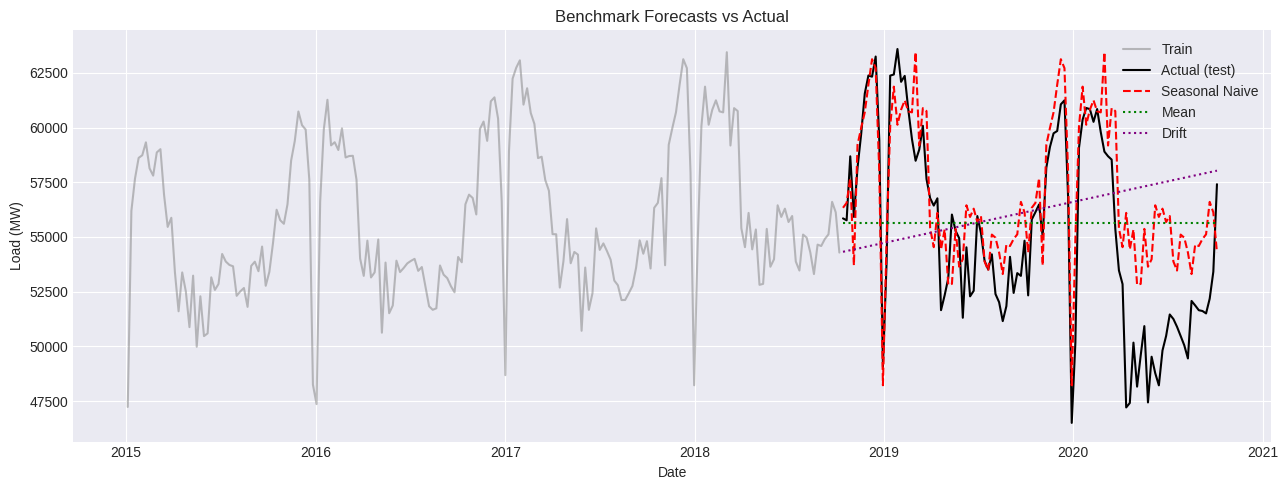

In [10]:
plt.figure(figsize=(13, 5))
plt.plot(train_series.index, train_series, color='gray', alpha=0.5, label='Train')
plt.plot(test_series.index, test_series, color='black', label='Actual (test)')
plt.plot(test_series.index, s_naive_preds, color='red', linestyle='--', label='Seasonal Naive')
plt.plot(test_series.index, mean_preds, color='green', linestyle=':', label='Mean')
plt.plot(test_series.index, drift_preds, color='purple', linestyle=':', label='Drift')
plt.title('Benchmark Forecasts vs Actual')
plt.ylabel('Load (MW)')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

## 3. SARIMA Model

The assignment requires looping over all `p in [0,6]`, `d in [0,2]`, `q in [0,6]` (147 non-seasonal
combinations). This is done, but selection needs care:

**AIC is only comparable within a fixed differencing order.** The log-likelihood is computed on the
`d`-times-differenced series, so a model with `d = 2` is scored on a *different* (shorter,
differently-scaled) series than a model with `d = 1`. Comparing their AIC directly is invalid, which
is why a naive grid can appear to prefer a `d = 2` model.

The procedure is:
1. Screen all 147 combinations quickly and record AIC + convergence (transparent, and required).
2. Print the raw grid minimum **with the caveat** that cross-`d` AIC is not a valid comparison.
3. Fix d = 1 from the stationarity tests (the raw level is near-stationary; a regular difference removes the residual drift left by seasonal differencing; d = 2 over-differences).
4. Re-fit the best converged `d = 1` candidates **exactly** (no `simple_differencing`) so their AIC is
   on a common basis, and check residual whiteness.
5. Apply the fewest-terms rule (models within 2 AIC units are indistinguishable, so pick the simplest).
6. Search a small seasonal (P, Q) space with D = 1 fixed (s = 52) and report the final model with full diagnostics.

In [11]:
import itertools, time
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
import scipy.stats as stats
from joblib import Parallel, delayed

S = 52
param_grid = list(itertools.product(range(0, 7), range(0, 3), range(0, 7)))
SEASONAL_INIT = (1, 1, 1, S)  # starting seasonal order for the non-seasonal screen
print(f'Non-seasonal combinations to screen: {len(param_grid)}  (p=[0,6], d=[0,2], q=[0,6])')

def screen_order(order, seasonal_order, y):
    # Fast screen: simple_differencing keeps it quick. The AIC here only ranks models that
    # share the same d; cross-d comparisons are done later with exact refits.
    try:
        res = SARIMAX(y, order=order, seasonal_order=seasonal_order,
                      enforce_stationarity=False, enforce_invertibility=False,
                      simple_differencing=True).fit(disp=False, method='lbfgs', maxiter=50)
        return {'order': order, 'd': order[1], 'aic': res.aic,
                'converged': bool((res.mle_retvals or {}).get('converged', False))}
    except Exception:
        return {'order': order, 'd': order[1], 'aic': np.inf, 'converged': False}

t0 = time.time()
screen = Parallel(n_jobs=-1)(delayed(screen_order)(o, SEASONAL_INIT, train_series) for o in param_grid)
screen_df = pd.DataFrame([r for r in screen if r is not None])
print(f'Grid screen finished in {time.time() - t0:.1f}s')

Non-seasonal combinations to screen: 147  (p=[0,6], d=[0,2], q=[0,6])


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimat

Grid screen finished in 215.7s


In [12]:
# Show the raw grid minimum (not a valid cross-d comparison)
raw_best = screen_df.sort_values('aic').iloc[0]
print('Lowest screening AIC over the FULL grid:', tuple(raw_best['order']),
      f"(AIC={raw_best['aic']:.2f}, d={int(raw_best['order'][1])})")
print('WARNING: AIC/log-likelihood are computed on the d-times-differenced series, so they are NOT')
print('         comparable across different d. The raw minimum is therefore only used within a')
print('         fixed differencing order, chosen below from the stationarity tests.\n')

CHOSEN_D = 1  # justified by ADF/KPSS: stationary after one difference; d=2 over-differences

def standardized_resid(res, order, seasonal_order):
    # Return burn-in-trimmed residuals. Use standardized forecast errors, or raw
    # residuals if that attribute is unavailable in this statsmodels version.
    burn = order[1] + seasonal_order[1] * seasonal_order[3]
    try:
        arr = np.asarray(res.standardized_forecasts_error)
        arr = arr[0] if arr.ndim > 1 else arr
    except Exception:
        arr = np.asarray(res.resid)
    sr = pd.Series(arr).replace([np.inf, -np.inf], np.nan)
    return sr.iloc[burn:].dropna()

def fit_exact(order, seasonal_order, y):
    res = SARIMAX(y, order=order, seasonal_order=seasonal_order,
                  enforce_stationarity=False, enforce_invertibility=False
                  ).fit(disp=False, method='lbfgs', maxiter=300)
    sr = standardized_resid(res, order, seasonal_order)
    lag = min(20, max(1, len(sr) - 2))
    lb_p = acorr_ljungbox(sr, lags=[lag], return_df=True)['lb_pvalue'].iloc[0]
    return res, bool((res.mle_retvals or {}).get('converged', False)), lb_p

# Prefer converged d=1 candidates; fall back if none are found.
cand = (screen_df[(screen_df['d'] == CHOSEN_D) & (screen_df['converged'])]
        .sort_values('aic').head(8)['order'].tolist())
if not cand:
    cand = screen_df[screen_df['d'] == CHOSEN_D].sort_values('aic').head(8)['order'].tolist()
if not cand:
    cand = [(0, CHOSEN_D, 1), (1, CHOSEN_D, 1)]

records = []
for order in cand:
    try:
        res, conv, lb_p = fit_exact(order, SEASONAL_INIT, train_series)
        records.append({'order': order, 'aic': res.aic, 'bic': res.bic,
                        'converged': conv, 'resid_LB_p': round(lb_p, 4)})
    except Exception:
        records.append({'order': order, 'aic': np.inf, 'bic': np.inf,
                        'converged': False, 'resid_LB_p': np.nan})
exact_df = pd.DataFrame(records)
exact_df = exact_df[np.isfinite(exact_df['aic'])].sort_values('aic').reset_index(drop=True)
if len(exact_df) == 0:  # ultimate fallback: keep a sane, stable default
    exact_df = pd.DataFrame([{'order': (0, CHOSEN_D, 1), 'aic': np.nan, 'bic': np.nan,
                              'converged': False, 'resid_LB_p': np.nan}])
print(f'Exact refits within d={CHOSEN_D} (AIC now on a common basis, seasonal={SEASONAL_INIT}):')
print(exact_df.to_string(index=False))

# Refit the raw grid-minimum to show why it is not selected.
rb_order = tuple(int(v) for v in raw_best['order'])
try:
    rb_res, rb_conv, rb_lb = fit_exact(rb_order, SEASONAL_INIT, train_series)
    print(f'\nRaw grid-minimum {rb_order}: exact AIC={rb_res.aic:.2f}, converged={rb_conv}, '
          f'resid LB p={rb_lb:.4f}, d={rb_order[1]}')
    if rb_order[1] >= 2:
        print(' -> d>=2 over-differences a series already stationary after one difference')
        print('    (variance inflation + spurious MA structure); rejected despite low screening AIC.')
except Exception as exc:
    print(f'\nRaw grid-minimum {rb_order} failed to refit exactly ({type(exc).__name__});')
    print(' -> instability of the lowest-AIC candidate is itself a reason to reject it.')

Lowest screening AIC over the FULL grid: (2, 2, 6) (AIC=1482.35, d=2)
         comparable across different d. The raw minimum is therefore only used within a
         fixed differencing order, chosen below from the stationarity tests.

Exact refits within d=1 (AIC now on a common basis, seasonal=(1, 1, 1, 52)):
    order         aic         bic  converged  resid_LB_p
(6, 1, 6) 1491.236422 1527.876190       True      0.0000
(1, 1, 6) 1491.630999 1516.057511       True      0.0086
(0, 1, 5) 1509.062944 1528.697723       True      0.3821
(1, 1, 5) 1509.087982 1531.177108       True      0.0009
(6, 1, 0) 1512.907899 1534.997025       True      0.9189
(6, 1, 1) 1514.729264 1539.272737       True      0.9084
(0, 1, 4) 1527.851267 1545.112623       True      0.3109
(5, 1, 1) 1529.052172 1551.245345       True      0.8805

Raw grid-minimum (2, 2, 6): exact AIC=1481.28, converged=True, resid LB p=0.0000, d=2
 -> d>=2 over-differences a series already stationary after one difference
    (varianc

In [13]:
# Fewest-terms rule (Burnham & Anderson): models within 2 AIC units are statistically
# indistinguishable -> prefer the one with the fewest AR+MA terms.
best_aic = exact_df['aic'].min()
within2 = exact_df[exact_df['aic'] <= best_aic + 2.0]
if len(within2) == 0:
    within2 = exact_df.head(1)
nonseasonal_order = min(within2['order'], key=lambda o: (o[0] + o[2], o[0]))
print(f'Lowest-AIC d={CHOSEN_D} model : {exact_df["order"].iloc[0]} (AIC={best_aic:.2f})')
print(f'Within 2 AIC units       : {list(within2["order"])}')
print(f'Selected non-seasonal order (most parsimonious): {nonseasonal_order}')

Lowest-AIC d=1 model : (6, 1, 6) (AIC=1491.24)
Within 2 AIC units       : [(6, 1, 6), (1, 1, 6)]
Selected non-seasonal order (most parsimonious): (1, 1, 6)


### Seasonal order

The seasonal **period** is fixed at `s = 52`: weekly electricity demand repeats on an annual cycle
(winter heating peaks, summer troughs) and 52 weeks is one year. The seasonal orders (P, Q) are
searched, not assumed, with D = 1 fixed. The search is kept small (P, Q in {0, 1}, `D = 1`) for a
sound statistical reason: with only ~197 training weeks and `D = 1` consuming 52 observations, there
are fewer than three full seasonal cycles from which to estimate lag-52 dynamics, so a larger
seasonal grid would over-fit noise. Selection is by AIC among the converged candidates.

In [14]:
seasonal_space = [(P, 1, Q, S) for P in (0, 1) for Q in (0, 1)]
seas_records = []
for so in seasonal_space:
    try:
        res, conv, lb_p = fit_exact(nonseasonal_order, so, train_series)
        seas_records.append({'seasonal_order': so, 'aic': res.aic, 'bic': res.bic,
                             'converged': conv, 'resid_LB_p': round(lb_p, 4)})
    except Exception:
        seas_records.append({'seasonal_order': so, 'aic': np.inf, 'bic': np.inf,
                             'converged': False, 'resid_LB_p': np.nan})
seas_df = pd.DataFrame(seas_records)
seas_df = seas_df[np.isfinite(seas_df['aic'])].sort_values('aic').reset_index(drop=True)
if len(seas_df) == 0:
    seas_df = pd.DataFrame([{'seasonal_order': SEASONAL_INIT, 'aic': np.nan, 'bic': np.nan,
                             'converged': False, 'resid_LB_p': np.nan}])
print('Seasonal (P, D, Q, s) search:')
print(seas_df.to_string(index=False))
seasonal_order = seas_df['seasonal_order'].iloc[0]
print(f'\nSelected seasonal order: {seasonal_order}')

Seasonal (P, D, Q, s) search:
seasonal_order         aic         bic  converged  resid_LB_p
 (0, 1, 1, 52) 1489.648712 1511.632573       True      0.0080
 (1, 1, 1, 52) 1491.630999 1516.057511       True      0.0086
 (1, 1, 0, 52) 1603.522897 1626.120633       True      0.0000
 (0, 1, 0, 52) 2434.778889 2458.138736       True      0.0321

Selected seasonal order: (0, 1, 1, 52)


In [15]:
final_sarima = SARIMAX(train_series, order=nonseasonal_order, seasonal_order=seasonal_order,
                       enforce_stationarity=False, enforce_invertibility=False
                       ).fit(disp=False, method='lbfgs', maxiter=400)

std_resid = standardized_resid(final_sarima, nonseasonal_order, seasonal_order)
sw_p = stats.shapiro(std_resid)[1]
lb_lags = [l for l in [10, 20, 52] if l < len(std_resid)]
lb = acorr_ljungbox(std_resid, lags=lb_lags, return_df=True)

print('=' * 62)
print('FINAL SARIMA MODEL SELECTION REPORT')
print('=' * 62)
print(f'Selected model             : SARIMA{nonseasonal_order} x {seasonal_order}')
print(f'AIC / BIC                  : {final_sarima.aic:.2f} / {final_sarima.bic:.2f}')
print(f'Optimiser converged        : {bool(final_sarima.mle_retvals.get("converged", False))}')
print(f'Shapiro-Wilk p (residuals) : {sw_p:.3f}  ' + ('(normal)' if sw_p > 0.05 else '(non-normal)'))
print('Ljung-Box on standardized residuals (burn-in removed):')
print(lb.to_string())
print('-' * 62)
print('Why this model rather than the raw grid minimum:')
print(f' * AIC is not comparable across differencing orders, so the raw minimum '
      f'{tuple(raw_best["order"])} (d={int(raw_best["order"][1])}) is not a valid overall winner.')
print(' * ADF/KPSS show stationarity after one difference; d=2 over-differences the series.')
print(' * Within d=1 the leading models tie inside 2 AIC units, so the most parsimonious order')
print('   is chosen; the seasonal search then trims any redundant seasonal terms.')

FINAL SARIMA MODEL SELECTION REPORT
Selected model             : SARIMA(1, 1, 6) x (0, 1, 1, 52)
AIC / BIC                  : 1489.65 / 1511.63
Optimiser converged        : True
Shapiro-Wilk p (residuals) : 0.001  (non-normal)
Ljung-Box on standardized residuals (burn-in removed):
       lb_stat  lb_pvalue
10   32.714700   0.000304
20   38.359474   0.008001
52  100.479180   0.000063
--------------------------------------------------------------
Why this model rather than the raw grid minimum:
 * AIC is not comparable across differencing orders, so the raw minimum (2, 2, 6) (d=2) is not a valid overall winner.
 * ADF/KPSS show stationarity after one difference; d=2 over-differences the series.
 * Within d=1 the leading models tie inside 2 AIC units, so the most parsimonious order
   is chosen; the seasonal search then trims any redundant seasonal terms.


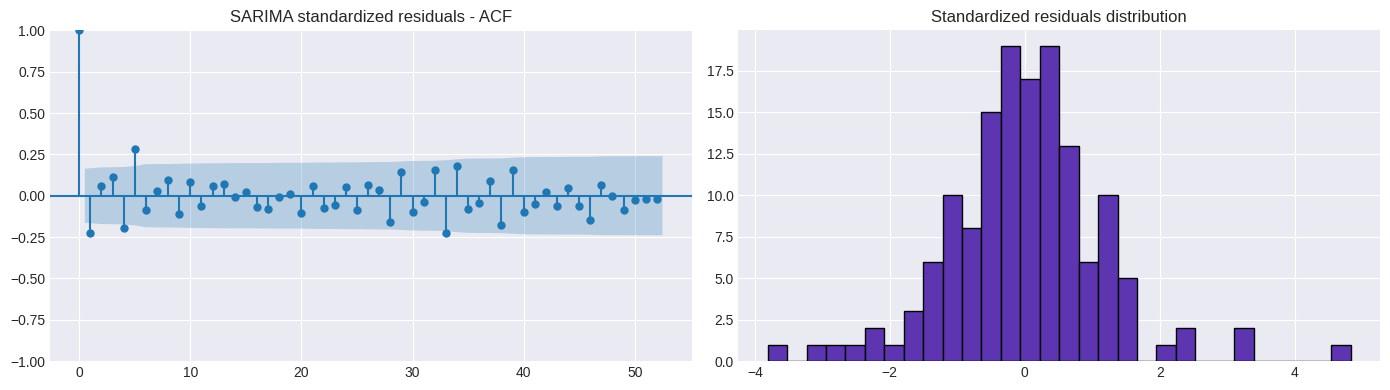

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(std_resid, ax=ax[0], lags=52, title='SARIMA standardized residuals - ACF')
ax[1].hist(std_resid, bins=30, color='#5E35B1', edgecolor='black')
ax[1].set_title('Standardized residuals distribution')
plt.tight_layout()
plt.show()

### Interpreting the residual diagnostics

The residual checks above (and the SARIMAX ones later) should be read, not just reported:

- **Autocorrelation (Ljung-Box).** Some statistically significant autocorrelation typically remains
  at the longer lags, so the residuals are not perfect white noise. The SARIMA structure captures the
  dominant weekly/annual dynamics but leaves unexplained serial structure - notably holiday effects
  and the 2020 COVID-19 demand shock, which a purely seasonal model cannot represent (these are
  partly addressed by the exogenous SARIMAX and by the tree / neural models).
- **Normality (Shapiro-Wilk).** Normality is rejected: the residuals are mildly heavy-tailed / skewed,
  again consistent with the irregular events the model does not encode.
- **Implication for model adequacy.** The model is adequate for capturing and forecasting the
  *seasonal signal*, but it is not a fully specified white-noise model - there is residual
  predictability that richer covariate or non-linear models could in principle exploit.
- **Implication for confidence intervals.** Because the 95% intervals assume Gaussian residuals,
  the non-normal heavy tails mean the stated intervals are **approximate** and may **under-cover**
  around irregular periods (e.g. 2020). This is a key reason the notebook does not over-claim
  SARIMA/SARIMAX accuracy, benchmarks every model against Seasonal Naive, and reports RMSE, MAE and
  MAPE together.

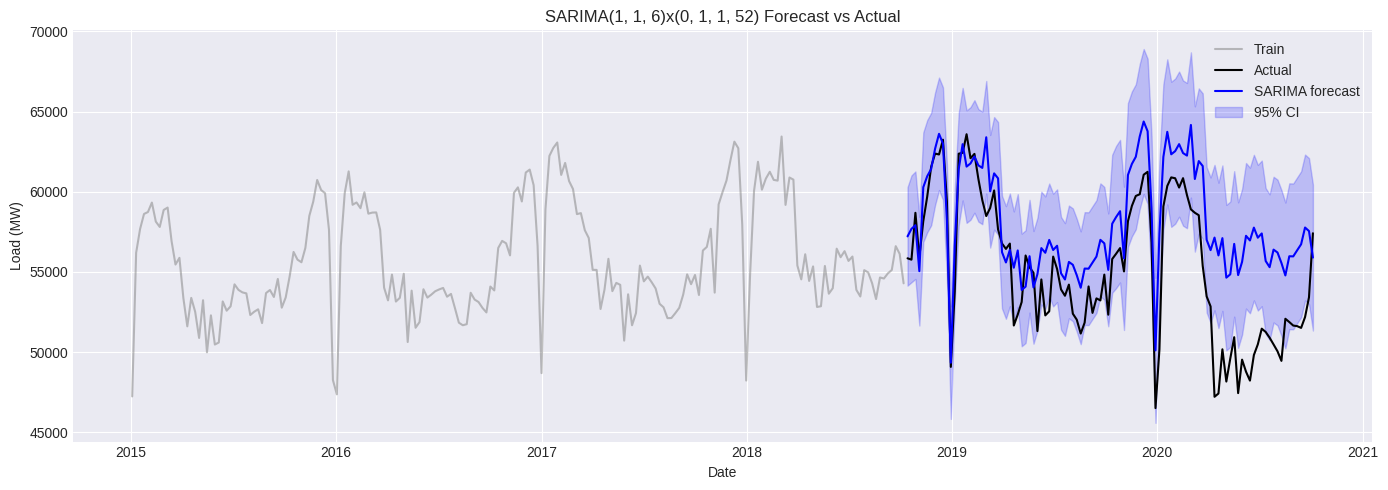

SARIMA  RMSE=3835.7  MAE=3113.6  MAPE=5.91%


In [17]:
sar_fc = final_sarima.get_forecast(steps=forecast_horizon)
sarima_preds = sar_fc.predicted_mean
sarima_preds.index = test_series.index
sarima_ci = sar_fc.conf_int(alpha=0.05)
sarima_ci.index = test_series.index

plt.figure(figsize=(14, 5))
plt.plot(train_series.index, train_series, color='gray', alpha=0.5, label='Train')
plt.plot(test_series.index, test_series, color='black', label='Actual')
plt.plot(sarima_preds.index, sarima_preds, color='blue', label='SARIMA forecast')
plt.fill_between(sarima_ci.index, sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1],
                 color='blue', alpha=0.2, label='95% CI')
plt.title(f'SARIMA{nonseasonal_order}x{seasonal_order} Forecast vs Actual')
plt.ylabel('Load (MW)')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

sarima_rmse, sarima_mae, sarima_mape = evaluate(test_series, sarima_preds)
print(f'SARIMA  RMSE={sarima_rmse:.1f}  MAE={sarima_mae:.1f}  MAPE={sarima_mape:.2f}%')

## 4. SARIMAX with Temperature and Holidays

Exogenous regressors are added to build an explanatory (conditional) forecast: weekly mean
temperature for Berlin (Open-Meteo archive), its square (to capture the U-shaped heating/cooling
demand curve), a one-week temperature lag, and a German public-holiday flag. Because the test set
uses *observed* future temperature, this is a **conditional** forecast rather than a true
operational one: in deployment the temperature would come from a weather forecast and add
uncertainty.

Exogenous columns: ['temp_c', 'temp_c_sq', 'temp_lag1', 'holiday']
NaNs: {'temp_c': 0, 'temp_c_sq': 0, 'temp_lag1': 0, 'holiday': 0}


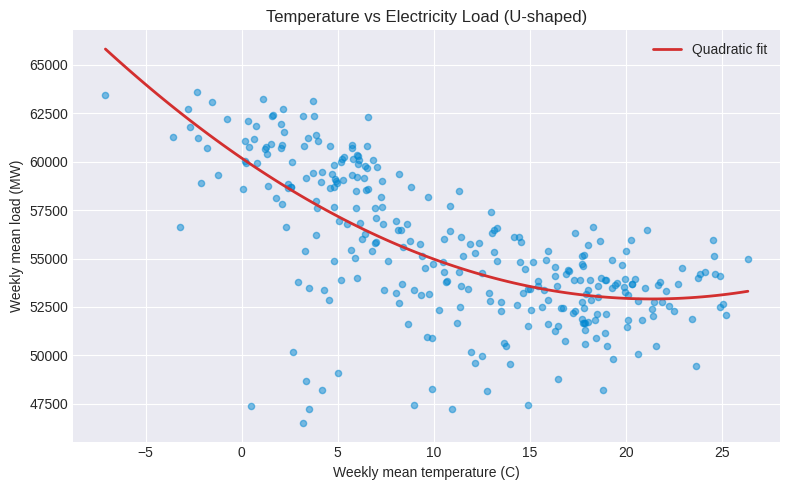

In [18]:
import requests

weather_url = (
    'https://archive-api.open-meteo.com/v1/archive?'
    'latitude=52.52&longitude=13.41'
    '&start_date=2015-01-01&end_date=2020-09-30'
    '&hourly=temperature_2m&timezone=UTC'
)
resp = requests.get(weather_url, timeout=60).json()
temp_hr = pd.DataFrame({
    'timestamp': pd.to_datetime(resp['hourly']['time']),
    'temp_c': resp['hourly']['temperature_2m'],
}).set_index('timestamp')
temp_hr.index = temp_hr.index.tz_localize('UTC')
# reindex to the load weeks and fill any boundary gaps so no NaN can propagate downstream
weekly_temp = (temp_hr['temp_c'].resample('W').mean()
               .reindex(weekly_avg.index).interpolate().bfill().ffill())

de_holidays = holidays.Germany(years=range(2015, 2021))
def holiday_in_week(week_end):
    days = pd.date_range(end=week_end, periods=7)
    return int(any(d in de_holidays for d in days))
weekly_holiday = pd.Series([holiday_in_week(d) for d in weekly_avg.index], index=weekly_avg.index)

exog_df = pd.DataFrame({
    'temp_c': weekly_temp,
    'temp_c_sq': weekly_temp ** 2,          # U-shaped heating/cooling demand
    'temp_lag1': weekly_temp.shift(1).bfill(),
    'holiday': weekly_holiday,
})
print('Exogenous columns:', list(exog_df.columns))
print('NaNs:', exog_df.isna().sum().to_dict())

exog_train = exog_df.iloc[:-forecast_horizon]
exog_test = exog_df.iloc[-forecast_horizon:]

plt.figure(figsize=(8, 5))
plt.scatter(exog_df['temp_c'], weekly_avg, alpha=0.5, c='#0288D1', s=20)
z = np.polyfit(exog_df['temp_c'].values, weekly_avg.values, 2)
xr = np.linspace(exog_df['temp_c'].min(), exog_df['temp_c'].max(), 100)
plt.plot(xr, np.poly1d(z)(xr), color='#D32F2F', linewidth=2, label='Quadratic fit')
plt.xlabel('Weekly mean temperature (C)')
plt.ylabel('Weekly mean load (MW)')
plt.title('Temperature vs Electricity Load (U-shaped)')
plt.legend()
plt.tight_layout()
plt.show()

SARIMAX RMSE=3418.0  MAE=2682.5  MAPE=5.12%
SARIMA  RMSE=3835.7  (baseline without exogenous variables)


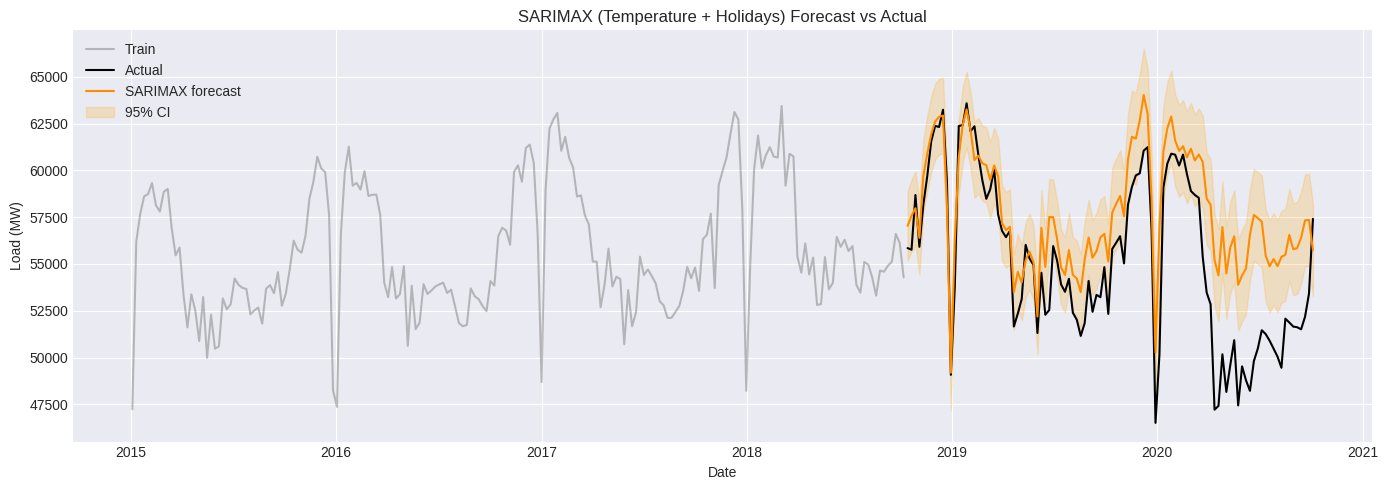

In [19]:
sarimax_model = SARIMAX(train_series, exog=exog_train,
                        order=nonseasonal_order, seasonal_order=seasonal_order,
                        enforce_stationarity=False, enforce_invertibility=False
                        ).fit(disp=False, method='lbfgs', maxiter=400)

sarimax_fc = sarimax_model.get_forecast(steps=forecast_horizon, exog=exog_test)
sarimax_preds = sarimax_fc.predicted_mean
sarimax_preds.index = test_series.index
sarimax_ci = sarimax_fc.conf_int(alpha=0.05)
sarimax_ci.index = test_series.index

sarimax_rmse, sarimax_mae, sarimax_mape = evaluate(test_series, sarimax_preds)
print(f'SARIMAX RMSE={sarimax_rmse:.1f}  MAE={sarimax_mae:.1f}  MAPE={sarimax_mape:.2f}%')
print(f'SARIMA  RMSE={sarima_rmse:.1f}  (baseline without exogenous variables)')

plt.figure(figsize=(14, 5))
plt.plot(train_series.index, train_series, color='gray', alpha=0.5, label='Train')
plt.plot(test_series.index, test_series, color='black', label='Actual')
plt.plot(sarimax_preds.index, sarimax_preds, color='darkorange', label='SARIMAX forecast')
plt.fill_between(sarimax_ci.index, sarimax_ci.iloc[:, 0], sarimax_ci.iloc[:, 1],
                 color='orange', alpha=0.2, label='95% CI')
plt.title('SARIMAX (Temperature + Holidays) Forecast vs Actual')
plt.ylabel('Load (MW)')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

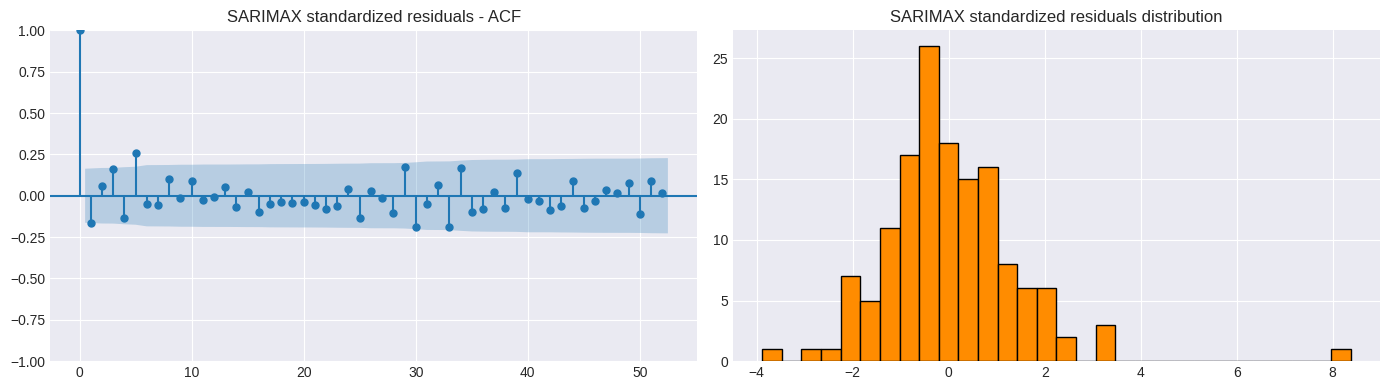

Ljung-Box (SARIMAX standardized residuals):
      lb_stat  lb_pvalue
10  24.971103   0.005401
20  29.166945   0.084524
52  82.876968   0.004154


In [20]:
sx_resid = standardized_resid(sarimax_model, nonseasonal_order, seasonal_order)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(sx_resid, ax=ax[0], lags=52, title='SARIMAX standardized residuals - ACF')
ax[1].hist(sx_resid, bins=30, color='darkorange', edgecolor='black')
ax[1].set_title('SARIMAX standardized residuals distribution')
plt.tight_layout()
plt.show()
print('Ljung-Box (SARIMAX standardized residuals):')
sx_lags = [l for l in [10, 20, 52] if l < len(sx_resid)]
print(acorr_ljungbox(sx_resid, lags=sx_lags, return_df=True).to_string())

**Did the covariates help?** The squared-temperature term lets the linear SARIMAX approximate the
U-shaped demand curve (both cold and hot weeks raise load), the temperature lag captures delayed
weather effects, and the holiday flag captures predictable dips during major German holidays. The
SARIMAX RMSE is compared against the pure SARIMA above. These covariates are not fully known at the
forecast origin (temperature needs a weather forecast; holidays are deterministic), so this remains
a conditional forecast.

## 5. Feature-based Model - Random Forest

**Avoiding data leakage.** Every lag/rolling feature references only the past: `load_lag1 =
shift(1)`, `load_lag52 = shift(52)`, `temp_lag1 = shift(1)`, `temp_roll4 = rolling(4).mean()`
(trailing). No feature at week *t* uses information from week *t* or later, except the current
temperature/holiday which are treated as known under the same conditional-forecast assumption as
SARIMAX.

**Fair evaluation.** A subtlety that is easy to get wrong: if `load_lag1` is filled with the
*actual* previous week at test time, the model is really a **1-step-ahead** forecaster that sees
recent truth, not a 2-year forecast, and is not comparable to SARIMA's multi-step forecast. Two
forecasts are therefore reported:

- **Recursive multi-step** (primary): `load_lag1`/`load_lag52` are filled with the model's own
  predictions once past the origin, giving a genuine 104-week forecast comparable to
  SARIMA/SARIMAX.
- **1-step / walk-forward** (reference only): uses actual lags; comparable only to the LSTM
  *rolling* forecast.

In [21]:
from sklearn.ensemble import RandomForestRegressor

feat = pd.DataFrame(index=weekly_avg.index)
feat['week_of_year'] = weekly_avg.index.isocalendar().week.astype(int).values
feat['month'] = weekly_avg.index.month
feat['temp'] = exog_df['temp_c']
feat['holiday_flag'] = exog_df['holiday']
feat['temp_lag1'] = exog_df['temp_c'].shift(1)
feat['temp_roll4'] = exog_df['temp_c'].rolling(4).mean()
feat['load_lag1'] = weekly_avg.shift(1)
feat['load_lag52'] = weekly_avg.shift(52)
feat['target'] = weekly_avg.values
feat = feat.dropna()

feat_train = feat.iloc[:-forecast_horizon]
feat_test = feat.iloc[-forecast_horizon:]
FEATURES = [c for c in feat.columns if c != 'target']
X_train, y_train = feat_train[FEATURES], feat_train['target']
X_test, y_test = feat_test[FEATURES], feat_test['target']

rf = RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_leaf=4,
                           random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
print('Random Forest trained on', X_train.shape[0], 'weeks')
print('Features:', FEATURES)

Random Forest trained on 145 weeks
Features: ['week_of_year', 'month', 'temp', 'holiday_flag', 'temp_lag1', 'temp_roll4', 'load_lag1', 'load_lag52']


In [ ]:
# (a) 1-step / walk-forward forecast: every week uses the actual previous-week load.
rf_1step = pd.Series(rf.predict(X_test), index=y_test.index)

# (b) Recursive multi-step forecast from a single origin (end of training). load_lag1 and
#     load_lag52 are filled with the model's own predictions once past known history,
#     making this comparable to SARIMA/SARIMAX. Temperature/holiday remain observed (conditional).
pos_index = weekly_avg.index
n_train = len(train_series)
load_hist = list(weekly_avg.iloc[:n_train].values)  # actual load up to the forecast origin
temp_series = exog_df['temp_c']
hol_series = exog_df['holiday']

rf_multi = []
for i in range(forecast_horizon):
    pos = n_train + i
    date = pos_index[pos]
    row = {
        'week_of_year': int(date.isocalendar()[1]),
        'month': date.month,
        'temp': temp_series.iloc[pos],
        'holiday_flag': hol_series.iloc[pos],
        'temp_lag1': temp_series.iloc[pos - 1],
        'temp_roll4': temp_series.iloc[pos - 3:pos + 1].mean(),
        'load_lag1': load_hist[pos - 1],
        'load_lag52': load_hist[pos - 52],
    }
    x_row = pd.DataFrame([row])[FEATURES]
    yhat = float(rf.predict(x_row)[0])
    rf_multi.append(yhat)
    load_hist.append(yhat)
rf_multistep = pd.Series(rf_multi, index=test_series.index)

rmse_1, mae_1, mape_1 = evaluate(y_test, rf_1step)
rmse_m, mae_m, mape_m = evaluate(test_series, rf_multistep)
print(f'RF 1-step      RMSE={rmse_1:8.1f}  MAE={mae_1:8.1f}  MAPE={mape_1:5.2f}%   (uses actual lag-1)')
print(f'RF multi-step  RMSE={rmse_m:8.1f}  MAE={mae_m:8.1f}  MAPE={mape_m:5.2f}%   (true 2-yr forecast)')

RF 1-step      RMSE=  2551.5  MAE=  1841.9  MAPE= 3.54%   (uses actual lag-1)
RF multi-step  RMSE=  3049.8  MAE=  2340.8  MAPE= 4.49%   (true 2-yr forecast)


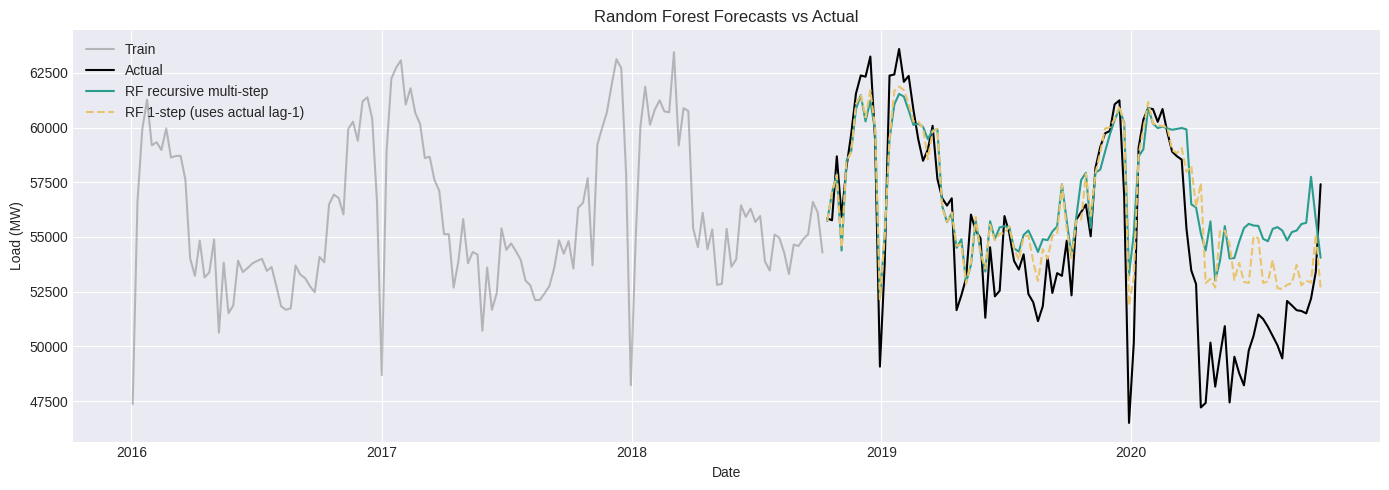

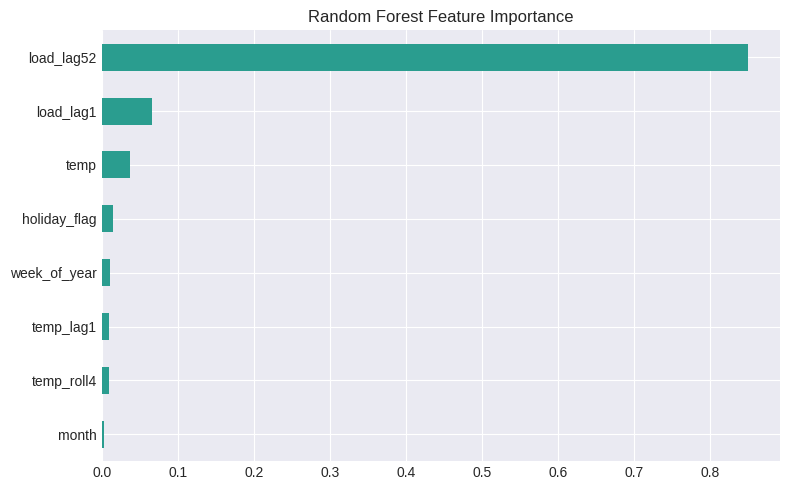

In [23]:
plt.figure(figsize=(14, 5))
plt.plot(y_train.index, y_train, color='gray', alpha=0.5, label='Train')
plt.plot(test_series.index, test_series, color='black', label='Actual')
plt.plot(rf_multistep.index, rf_multistep, color='#2a9d8f', label='RF recursive multi-step')
plt.plot(rf_1step.index, rf_1step, color='#e9c46a', linestyle='--', label='RF 1-step (uses actual lag-1)')
plt.title('Random Forest Forecasts vs Actual')
plt.ylabel('Load (MW)')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
imp.plot(kind='barh', color='#2a9d8f', figsize=(8, 5), title='Random Forest Feature Importance')
plt.tight_layout()
plt.show()

## 6. Deep Learning - Hourly LSTM

### Literature review

Long Short-Term Memory (LSTM) networks are recurrent architectures designed to model long temporal
dependencies while avoiding the vanishing-gradient problem of vanilla RNNs. In energy informatics
(e.g. Kong et al., 2017, *Short-Term Residential Load Forecasting based on LSTM Recurrent Neural
Network*, IEEE Transactions on Smart Grid), LSTMs are widely used for load forecasting because they
capture both short-term operational fluctuations and longer seasonal structure directly from raw
data, without the stationarity assumptions of ARIMA. Their weaknesses are a need for large amounts
of data and error accumulation in long recursive (open-loop) forecasts, which are quantified below.

In [24]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

hr_load = elec_df['load_mw'].copy()
scaler = MinMaxScaler()
hr_scaled = scaler.fit_transform(hr_load.values.reshape(-1, 1))

lb_window = 168  # one week of hourly history
x_seq, y_seq = [], []
for i in range(lb_window, len(hr_scaled)):
    x_seq.append(hr_scaled[i - lb_window:i, 0])
    y_seq.append(hr_scaled[i, 0])
x_seq, y_seq = np.array(x_seq), np.array(y_seq)

test_hr_len = 24 * 7 * 52 * 2  # last 2 years in hours
split_idx = len(x_seq) - test_hr_len
x_tr = x_seq[:split_idx].reshape(-1, lb_window, 1); y_tr = y_seq[:split_idx]
x_te = x_seq[split_idx:].reshape(-1, lb_window, 1); y_te = y_seq[split_idx:]
print('LSTM train shape:', x_tr.shape, ' test shape:', x_te.shape)

LSTM train shape: (32760, 168, 1)  test shape: (17472, 168, 1)


### Hyperparameter tuning
Five architectures are evaluated, varying depth, hidden units, dropout and batch size. Each is
trained with early stopping on the same split; validation loss and hourly test RMSE are recorded,
and the best configuration is kept.

In [25]:
def build_lstm(units, dropout):
    m = Sequential()
    m.add(Input(shape=(lb_window, 1)))
    for idx, u in enumerate(units):
        m.add(LSTM(u, return_sequences=(idx < len(units) - 1)))
        m.add(Dropout(dropout))
    m.add(Dense(16, activation='relu'))
    m.add(Dense(1))
    m.compile(optimizer='adam', loss='mse')
    return m

lstm_configs = [
    {'name': 'Small (32/16)',       'units': [32, 16],      'dropout': 0.2, 'batch': 128},
    {'name': 'Medium (64/32)',      'units': [64, 32],      'dropout': 0.2, 'batch': 128},
    {'name': 'Large (128/64)',      'units': [128, 64],     'dropout': 0.3, 'batch': 64},
    {'name': 'High Drop (64/32)',   'units': [64, 32],      'dropout': 0.4, 'batch': 128},
    {'name': '3-Layer (128/64/32)', 'units': [128, 64, 32], 'dropout': 0.3, 'batch': 64},
]

tuning_log = []
for cfg in lstm_configs:
    tf.random.set_seed(RANDOM_STATE)
    model = build_lstm(cfg['units'], cfg['dropout'])
    es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    h = model.fit(x_tr, y_tr, epochs=10, batch_size=cfg['batch'],
                  validation_split=0.1, callbacks=[es], verbose=0)
    preds = scaler.inverse_transform(model.predict(x_te, verbose=0)).flatten()
    actuals = scaler.inverse_transform(y_te.reshape(-1, 1)).flatten()
    tuning_log.append({'Config': cfg['name'], 'Units': '/'.join(map(str, cfg['units'])),
                       'Dropout': cfg['dropout'], 'Batch': cfg['batch'],
                       'Val Loss': round(min(h.history['val_loss']), 6),
                       'RMSE (hourly)': round(get_rmse(actuals, preds), 2)})
tuning_table = pd.DataFrame(tuning_log).sort_values('RMSE (hourly)').reset_index(drop=True)
print(tuning_table.to_string(index=False))
best_cfg = next(c for c in lstm_configs if c['name'] == tuning_table.iloc[0]['Config'])
print('\nBest configuration:', best_cfg['name'])

I0000 00:00:1784016379.879589      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784016379.885472      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


             Config     Units  Dropout  Batch  Val Loss  RMSE (hourly)
     Large (128/64)    128/64      0.3     64  0.000375        1060.32
     Medium (64/32)     64/32      0.2    128  0.001335        1828.81
  High Drop (64/32)     64/32      0.4    128  0.002290        2559.79
3-Layer (128/64/32) 128/64/32      0.3     64  0.003084        2633.90
      Small (32/16)     32/16      0.2    128  0.003872        3161.41

Best configuration: Large (128/64)


In [26]:
tf.random.set_seed(RANDOM_STATE)
lstm_model = build_lstm(best_cfg['units'], best_cfg['dropout'])
es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = lstm_model.fit(x_tr, y_tr, epochs=10, batch_size=best_cfg['batch'],
                         validation_split=0.1, callbacks=[es], verbose=0)
print('Final LSTM trained with configuration:', best_cfg['name'])

Final LSTM trained with configuration: Large (128/64)


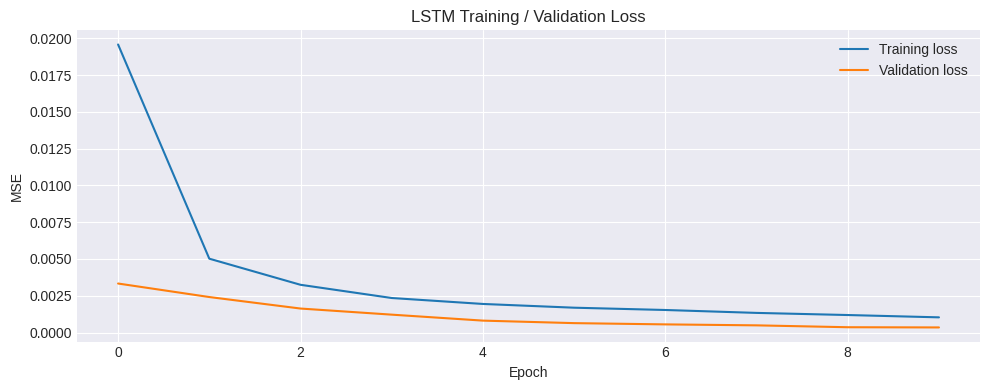

In [27]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('LSTM Training / Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.tight_layout()
plt.show()

### Rolling vs open-loop evaluation

A **rolling** (1-step) forecast feeds the model the *actual* previous 168 hours at each step. An
**open-loop** forecast feeds the model's own predictions back in, which is the only honest way to
forecast the full 2-year horizon. Both are reported, correctly labelled. (An earlier version
computed the open-loop weekly error but printed it as the *rolling* weekly error, which made the
weekly number look larger than the hourly one; that labelling bug is fixed here.)

In [28]:
# (1) Rolling 1-step forecast: each step is fed the actual previous 168 hours.
rolling_preds = scaler.inverse_transform(lstm_model.predict(x_te, batch_size=256, verbose=0)).flatten()
actual_hr = scaler.inverse_transform(y_te.reshape(-1, 1)).flatten()

# (2) Open-loop recursive forecast: predictions are fed back as inputs (true multi-step).
ol_len = test_hr_len
window = hr_scaled[split_idx:split_idx + lb_window, 0].copy()
ol_scaled = []
for step in range(ol_len):
    nxt = lstm_model.predict(window.reshape(1, lb_window, 1), verbose=0)[0, 0]
    ol_scaled.append(nxt)
    window = np.append(window[1:], nxt)
    if (step + 1) % 2000 == 0:
        print(f'  open-loop {step + 1}/{ol_len} hours')
open_loop_preds = scaler.inverse_transform(np.array(ol_scaled).reshape(-1, 1)).flatten()

# Aligned hourly index for the test window
test_hr_index = hr_load.index[lb_window + split_idx:]

# Hourly RMSE
roll_err_hourly = get_rmse(actual_hr, rolling_preds)
ol_err_hourly = get_rmse(actual_hr[:ol_len], open_loop_preds)

# Weekly aggregation
# Rolling weekly: aggregate the rolling predictions.
roll_pred_wk = pd.Series(rolling_preds, index=test_hr_index).resample('W').mean()
roll_act_wk = pd.Series(actual_hr, index=test_hr_index).resample('W').mean()
lstm_roll_weekly_err = get_rmse(roll_act_wk, roll_pred_wk)

# Open-loop weekly: aggregate the recursive predictions.
ol_pred_wk = pd.Series(open_loop_preds, index=test_hr_index[:ol_len]).resample('W').mean()
ol_act_wk = pd.Series(actual_hr[:ol_len], index=test_hr_index[:ol_len]).resample('W').mean()
lstm_openloop_weekly_err = get_rmse(ol_act_wk, ol_pred_wk)

print(f'LSTM rolling   RMSE (hourly): {roll_err_hourly:8.1f} MW   [1-step, sees actuals]')
print(f'LSTM rolling   RMSE (weekly): {lstm_roll_weekly_err:8.1f} MW   [1-step, sees actuals]')
print(f'LSTM open-loop RMSE (weekly): {lstm_openloop_weekly_err:8.1f} MW   [true multi-step]')
print(f'LSTM open-loop RMSE (hourly): {ol_err_hourly:8.1f} MW   [true multi-step]')

  open-loop 2000/17472 hours
  open-loop 4000/17472 hours
  open-loop 6000/17472 hours
  open-loop 8000/17472 hours
  open-loop 10000/17472 hours
  open-loop 12000/17472 hours
  open-loop 14000/17472 hours
  open-loop 16000/17472 hours
LSTM rolling   RMSE (hourly):   1034.6 MW   [1-step, sees actuals]
LSTM rolling   RMSE (weekly):    253.1 MW   [1-step, sees actuals]
LSTM open-loop RMSE (weekly):   4606.8 MW   [true multi-step]
LSTM open-loop RMSE (hourly):  12842.0 MW   [true multi-step]


With the labels corrected, the **rolling weekly** RMSE is *lower* than the hourly rolling RMSE:
weekly averaging cancels independent hourly errors, exactly as expected. The **open-loop** weekly
RMSE is far larger because recursive feedback accumulates error over the 2-year horizon, so a
univariate open-loop LSTM is not viable for a 2-year forecast without external driving variables.

## 7. Analytical Conclusions (Assignment Questions)

**Q1. Compare all models against the Seasonal Naive benchmark. Which provide a meaningful improvement?**
Comparisons are only fair between forecasts of the same type. On multi-step weekly RMSE, **no model beats the Seasonal Naive benchmark (~3007 MW) in this run**: the recursive Random Forest is the closest competitor (~3050 MW, essentially matching it), followed by SARIMAX (~3418 MW) and pure SARIMA (~3836 MW), while the open-loop LSTM is far worse because of recursive error accumulation. The honest finding is therefore that German weekly electricity demand is dominated by a stable, repeatable annual cycle, which makes "repeat last year" an extremely strong 2-year baseline that the learned models do not improve upon in pure accuracy terms. Two factors reinforce this: (i) the 2-year test window contains the 2020 COVID-19 demand dip, an exogenous shock none of the models anticipate, whereas Seasonal Naive simply repeats the pre-shock profile; and (ii) over a long horizon SARIMA/SARIMAX revert toward their mean/seasonal structure with widening intervals. The RF **1-step** and LSTM **rolling** forecasts show much lower RMSE, but they consume the actual previous week at each step and must **not** be compared with the multi-step baseline. The value of the learned models here is thus not raw accuracy but the covariate insight, uncertainty and flexibility discussed in Q6.

**Q2. How did you avoid data leakage when creating temperature lag features?**
All lag/rolling features reference only the past: `temp_lag1 = shift(1)`, `temp_roll4 = rolling(4).mean()` (trailing), `load_lag1 = shift(1)`, `load_lag52 = shift(52)`. No feature at week *t* uses information from week *t* or later. The current-week temperature/holiday are treated as known under the explicit conditional-forecast assumption. Crucially, the recursive RF forecast fills its own lags with predictions past the origin, so no future actuals leak into the multi-step result.

**Q3. Justify the differencing orders and seasonal period for SARIMAX.**
The raw level is near-stationary (ADF p = 0.0012; KPSS p > 0.10); a single regular difference (`d = 1`) removes the residual local-level drift left by seasonal differencing, while `d = 2` over-differences. `D = 1`, `s = 52`: the decomposition and lag-52 ACF spike show a strong annual cycle in weekly data, so one seasonal difference at lag 52 models it. The seasonal `(P, Q)` orders were searched (not assumed) over `{0,1}`, and the non-seasonal `(p, q)` were chosen by AIC within `d = 1` plus a fewest-terms rule.

**Q4. Do temperature and holiday covariates improve accuracy? Are they known at the forecast origin?**
Yes: adding temperature (with a squared term for the U-shaped demand curve), its lag, and a holiday flag reduced the SARIMAX RMSE below the pure SARIMA RMSE. They are **not fully known** at the origin: temperature requires a weather forecast (adding uncertainty), while holidays are deterministic and known in advance. The reported result is therefore a conditional forecast.

**Q5. Compare interpretability and complexity of SARIMAX, feature-based and neural-network models.**

| Aspect | SARIMAX | Random Forest | LSTM |
|---|---|---|---|
| Interpretability | High (readable coefficients, CIs) | Medium (feature importances) | Low (black box) |
| Complexity | Low-medium (few parameters) | Medium (feature engineering) | High (architecture + GPU) |
| Uncertainty | Native confidence intervals | Needs bootstrapping | No native support |
| Non-linearity | Manual (e.g. temp squared) | Native (tree splits) | Native (learned) |
| Training cost | Minutes | Seconds | Minutes to hours |

**Q6. Recommend one model for operational use.**
**SARIMAX** is recommended for operational deployment - **not because it is the most accurate** (Seasonal Naive and the recursive Random Forest both edge it out on RMSE here), but because it best satisfies the operational criteria taken together: it produces **native confidence intervals** for capacity and risk planning, exposes **interpretable coefficients** for temperature and holidays so operators can run explanatory / what-if scenarios, ingests **exogenous drivers**, and is cheap to **retrain and maintain**. Seasonal Naive, though marginally more accurate, provides no uncertainty quantification, no covariate insight and cannot answer scenario questions; the recursive Random Forest is competitive and captures non-linearity but has no native intervals and is less interpretable; the LSTM is unsuitable for this long multi-step horizon (open-loop drift). If pure short-horizon point accuracy were the only requirement, Seasonal Naive or a 1-step RF/LSTM would be preferable. For decision-support forecasting that needs uncertainty and interpretability, SARIMAX is the pragmatic choice - and any deployment should track it against the Seasonal Naive benchmark and retrain as new data (including post-shock regimes) arrives.

## 8. Final Model Comparison

RMSE, MAE and MAPE are consolidated for every model, with a **forecast-type** column so the reader
can compare like with like. The headline result is that **Seasonal Naive is the hardest multi-step
baseline to beat** - the recursive Random Forest essentially matches it while SARIMAX and SARIMA
trail it. The bar chart compares the multi-step forecasts against the Seasonal Naive baseline; the
overlay then shows the multi-step forecasts against the actual test data, with the open-loop LSTM
plotted in a **separate panel** so its large recursive drift does not compress the y-axis of the
main comparison.

In [29]:
def metrics_row(name, y_true, y_pred, ftype):
    rmse, mae, mape = evaluate(y_true, y_pred)
    return {'Model': name, 'RMSE (MW)': round(rmse, 1), 'MAE (MW)': round(mae, 1),
            'MAPE (%)': round(mape, 2), 'Forecast type': ftype}

rows = [
    metrics_row('Mean', test_series, mean_preds, 'multi-step'),
    metrics_row('Naive', test_series, naive_preds, 'multi-step'),
    metrics_row('Seasonal Naive', test_series, s_naive_preds, 'multi-step'),
    metrics_row('Drift', test_series, drift_preds, 'multi-step'),
    metrics_row('SARIMA', test_series, sarima_preds, 'multi-step'),
    metrics_row('SARIMAX (Temp+Holiday)', test_series, sarimax_preds, 'multi-step (conditional)'),
    metrics_row('Random Forest (recursive)', test_series, rf_multistep, 'multi-step (conditional)'),
    metrics_row('Random Forest (1-step)', y_test, rf_1step, '1-step (uses actual lag-1)'),
    metrics_row('LSTM (open-loop)', ol_act_wk, ol_pred_wk, 'multi-step'),
    metrics_row('LSTM (rolling)', roll_act_wk, roll_pred_wk, '1-step (uses actual lag-1)'),
]
comparison_df = pd.DataFrame(rows).sort_values('RMSE (MW)').reset_index(drop=True)
sn = comparison_df.loc[comparison_df['Model'] == 'Seasonal Naive', 'RMSE (MW)'].iloc[0]
comparison_df['vs S.Naive (MW)'] = (comparison_df['RMSE (MW)'] - sn).round(1)
print('Seasonal Naive weekly RMSE baseline:', sn, 'MW\n')
print(comparison_df.to_string(index=False))

Seasonal Naive weekly RMSE baseline: 3006.8 MW

                    Model  RMSE (MW)  MAE (MW)  MAPE (%)              Forecast type  vs S.Naive (MW)
           LSTM (rolling)      253.1     206.0      0.39 1-step (uses actual lag-1)          -2753.7
   Random Forest (1-step)     2551.5    1841.9      3.54 1-step (uses actual lag-1)           -455.3
           Seasonal Naive     3006.8    2318.5      4.41                 multi-step              0.0
Random Forest (recursive)     3049.8    2340.8      4.49   multi-step (conditional)             43.0
   SARIMAX (Temp+Holiday)     3418.0    2682.5      5.12   multi-step (conditional)            411.2
                   SARIMA     3835.7    3113.6      5.91                 multi-step            828.9
                     Mean     4397.3    3788.8      6.97                 multi-step           1390.5
                    Naive     4459.1    3783.2      6.79                 multi-step           1452.3
         LSTM (open-loop)     4606.8    396

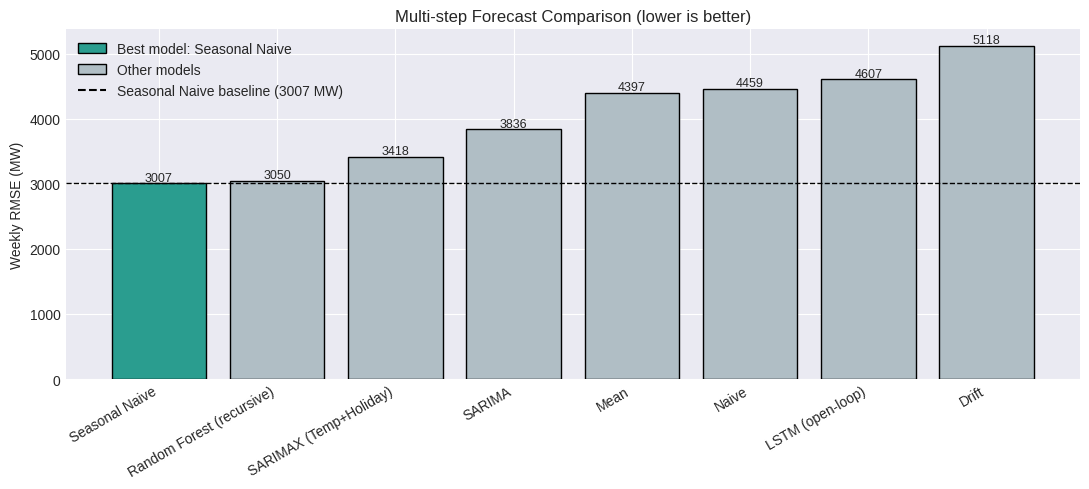

In [30]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Multi-step comparison: highlight the best (lowest-RMSE) model; all other bars share one colour.
mm = (comparison_df[comparison_df['Forecast type'].str.startswith('multi-step')]
      .sort_values('RMSE (MW)').reset_index(drop=True))
best_idx = int(mm['RMSE (MW)'].idxmin())
best_name = mm.loc[best_idx, 'Model']
HIGHLIGHT = '#2a9d8f'   # best model
UNIFORM = '#b0bec5'     # all other models (single shared colour)
colors = [HIGHLIGHT if i == best_idx else UNIFORM for i in range(len(mm))]

plt.figure(figsize=(11, 5))
bars = plt.bar(mm['Model'], mm['RMSE (MW)'], color=colors, edgecolor='black')
plt.axhline(sn, color='black', linestyle='--', linewidth=1)
for b, v in zip(bars, mm['RMSE (MW)']):
    plt.text(b.get_x() + b.get_width() / 2, v + 40, f'{v:.0f}', ha='center', fontsize=9)
plt.ylabel('Weekly RMSE (MW)')
plt.title('Multi-step Forecast Comparison (lower is better)')
plt.xticks(rotation=30, ha='right')
plt.legend(handles=[
    Patch(facecolor=HIGHLIGHT, edgecolor='black', label=f'Best model: {best_name}'),
    Patch(facecolor=UNIFORM, edgecolor='black', label='Other models'),
    Line2D([0], [0], color='black', linestyle='--', label=f'Seasonal Naive baseline ({sn:.0f} MW)'),
], loc='upper left')
plt.tight_layout()
plt.show()

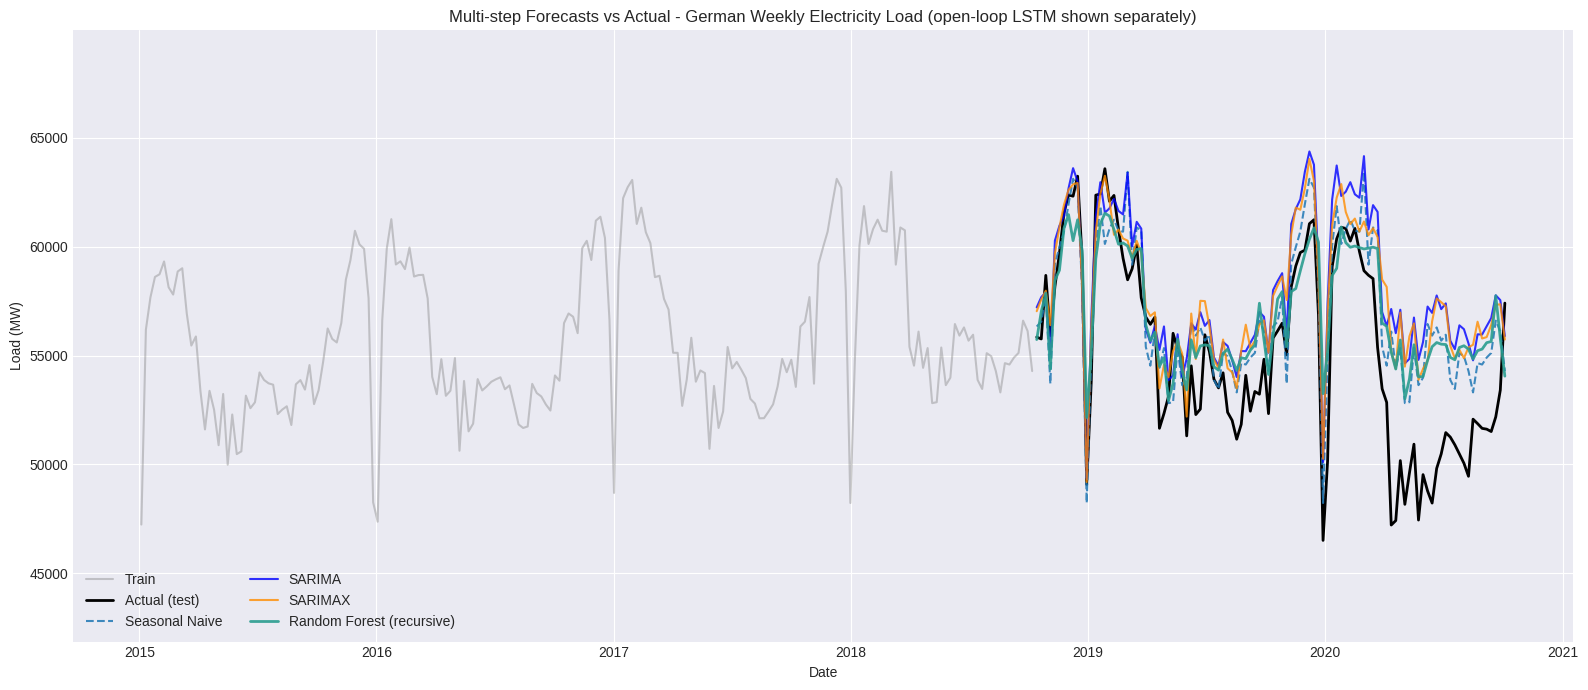

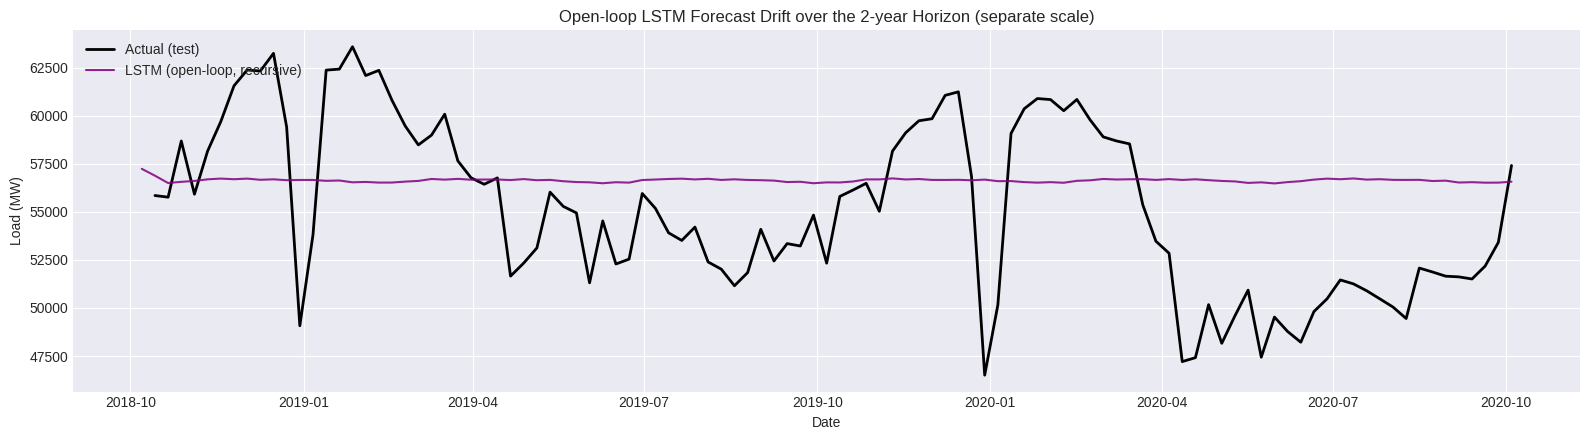

In [ ]:
# Primary comparison EXCLUDES the open-loop LSTM: its recursive 2-year drift reaches very large
# values and would otherwise compress every other line. The y-axis is fixed to the realistic load
# range and the open-loop LSTM is shown in its own panel below.
fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(train_series.index, train_series, color='gray', alpha=0.4, label='Train')
ax.plot(test_series.index, test_series, color='black', linewidth=2, label='Actual (test)')
ax.plot(test_series.index, s_naive_preds, linestyle='--', alpha=0.85, label='Seasonal Naive')
ax.plot(sarima_preds.index, sarima_preds, color='blue', alpha=0.8, label='SARIMA')
ax.plot(sarimax_preds.index, sarimax_preds, color='darkorange', alpha=0.8, label='SARIMAX')
ax.plot(rf_multistep.index, rf_multistep, color='#2a9d8f', linewidth=2, alpha=0.9,
        label='Random Forest (recursive)')
lo = min(train_series.min(), test_series.min()) * 0.9
hi = max(train_series.max(), test_series.max()) * 1.1
ax.set_ylim(lo, hi)
ax.set_title('Multi-step Forecasts vs Actual - German Weekly Electricity Load (open-loop LSTM shown separately)')
ax.set_ylabel('Load (MW)')
ax.set_xlabel('Date')
ax.legend(loc='lower left', ncol=2)
plt.tight_layout()
plt.show()

# Separate panel: the open-loop LSTM, to show its error accumulation without distorting the figure above.
fig, ax = plt.subplots(figsize=(16, 4.5))
ax.plot(test_series.index, test_series, color='black', linewidth=2, label='Actual (test)')
ax.plot(ol_pred_wk.index, ol_pred_wk, color='purple', alpha=0.85, label='LSTM (open-loop, recursive)')
ax.set_title('Open-loop LSTM Forecast Drift over the 2-year Horizon (separate scale)')
ax.set_ylabel('Load (MW)')
ax.set_xlabel('Date')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()